
# Практика по PyTorch

**Цель:** приближать функцию  
\[ f(x, y) = \sin(x + 2y)\, \exp\big(-\,(2x + y)^2\big) \]
на диапазоне \([-10, 10]\) по \(x\) и \(y\) с помощью нейронной сети в PyTorch.

**Что делаем:**
- Генерируем 20 000 случайных точек на квадрате \([-10, 10]^2\).
- Делим датасет на `train/val/test = 70%/15%/15%`.
- Строим MLP-модель в PyTorch, обучаем с **ранней остановкой**.
- Считаем **MSE** на тесте.
- Рисуем графики сравнения истинной функции и предсказаний модели.


In [3]:

# Проверка окружения и версии PyTorch
import sys, platform, torch
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


Python: 3.12.11
Platform: Linux-6.1.123+-x86_64-with-glibc2.35
PyTorch version: 2.8.0+cu126
CUDA available: True


device(type='cuda')

In [7]:

#@title Импорты, фиксируем случайность, определяем целевую функцию
import math
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Для воспроизводимости
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Целевая функция
def target_function(x, y):
    # x, y: torch.Tensor одной формы
    return torch.sin(x + 2*y) * torch.exp(-((2*x + y)**2))


In [8]:

#@title Генерируем датасет из 20 000 случайных точек и делим на train/val/test
N = 20_000
low, high = -10.0, 10.0

# Сэмплинг из равномерного распределения
x_all = torch.empty(N).uniform_(low, high)
y_all = torch.empty(N).uniform_(low, high)
z_all = target_function(x_all, y_all)

# Фичи и цель
X = torch.stack([x_all, y_all], dim=1)  # shape: [N, 2]
y = z_all.unsqueeze(1)                  # shape: [N, 1]

# Перемешиваем и делим на доли
idx = torch.randperm(N)
X = X[idx]
y = y[idx]

n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val

X_train, y_train = X[:n_train], y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:], y[n_train+n_val:]

X_train.shape, X_val.shape, X_test.shape


(torch.Size([14000, 2]), torch.Size([3000, 2]), torch.Size([3000, 2]))

In [9]:

#@title DataLoader'ы
batch_size = 512

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val, y_val)
test_ds  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)


In [10]:

#@title Определяем MLP-модель
class MLP(nn.Module):
    def __init__(self, in_dim=2, hidden=(128, 128, 64), out_dim=1, activation='tanh'):
        super().__init__()
        act = nn.Tanh if activation == 'tanh' else nn.ReLU
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), act()]
            prev = h
        layers += [nn.Linear(prev, out_dim)]
        self.net = nn.Sequential(*layers)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
model


MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [11]:

#@title Настраиваем обучение (MSELoss, Adam) и раннюю остановку
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float('inf')
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        improved = (self.best - val_loss) > self.min_delta
        if improved:
            self.best = val_loss
            self.counter = 0
            # Запоминаем лучшие веса
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return improved

early_stopping = EarlyStopping(patience=20, min_delta=1e-6)

max_epochs = 500

train_history = []
val_history = []


In [12]:

#@title Цикл обучения с валидацией и ранней остановкой
for epoch in range(1, max_epochs + 1):
    # ---- train ----
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.detach().cpu().item())
    train_loss = float(np.mean(train_losses))

    # ---- validation ----
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_losses.append(loss.detach().cpu().item())
    val_loss = float(np.mean(val_losses))

    train_history.append(train_loss)
    val_history.append(val_loss)

    if early_stopping.step(val_loss, model):
        status = " (improved)"
    else:
        status = ""

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train: {train_loss:.6f} | val: {val_loss:.6f}{status} | patience: {early_stopping.counter}/{early_stopping.patience}")

    if early_stopping.counter >= early_stopping.patience:
        print(f"Early stopping on epoch {epoch}. Best val loss: {early_stopping.best:.6f}")
        break

# Загружаем лучшие веса перед тестом
if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)


Epoch 001 | train: 0.054745 | val: 0.025079 (improved) | patience: 0/20
Epoch 010 | train: 0.015251 | val: 0.017957 | patience: 4/20
Epoch 020 | train: 0.015053 | val: 0.017287 (improved) | patience: 0/20
Epoch 030 | train: 0.014750 | val: 0.017394 | patience: 6/20
Epoch 040 | train: 0.014401 | val: 0.016959 | patience: 1/20
Epoch 050 | train: 0.013764 | val: 0.015466 | patience: 2/20
Epoch 060 | train: 0.013438 | val: 0.015756 | patience: 2/20
Epoch 070 | train: 0.013566 | val: 0.014552 | patience: 1/20
Epoch 080 | train: 0.012761 | val: 0.013888 (improved) | patience: 0/20
Epoch 090 | train: 0.012438 | val: 0.014142 | patience: 6/20
Epoch 100 | train: 0.012392 | val: 0.013351 | patience: 3/20
Epoch 110 | train: 0.010334 | val: 0.011705 (improved) | patience: 0/20
Epoch 120 | train: 0.006304 | val: 0.006261 (improved) | patience: 0/20
Epoch 130 | train: 0.002954 | val: 0.003168 (improved) | patience: 0/20
Epoch 140 | train: 0.002039 | val: 0.001777 (improved) | patience: 0/20
Epoch 15

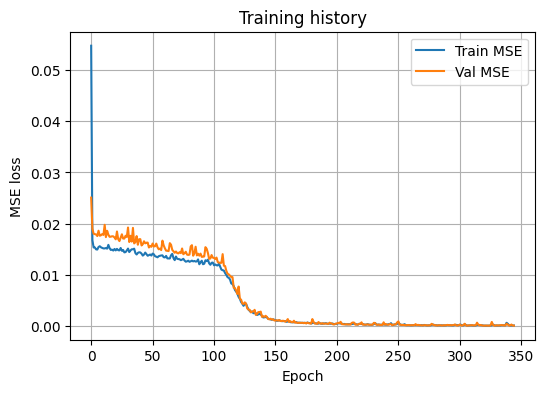

In [13]:

#@title График истории обучения (Train vs Val MSE)
plt.figure(figsize=(6,4))
plt.plot(train_history, label="Train MSE")
plt.plot(val_history, label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training history")
plt.legend()
plt.grid(True)
plt.show()


In [14]:

#@title Оценка на тесте: MSE
model.eval()
test_losses = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss = criterion(preds, yb)
        test_losses.append(loss.detach().cpu().item())
test_mse = float(np.mean(test_losses))
print("Test MSE:", test_mse)


Test MSE: 7.46986970625585e-05


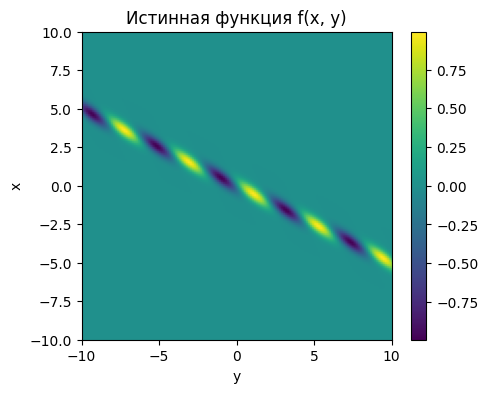

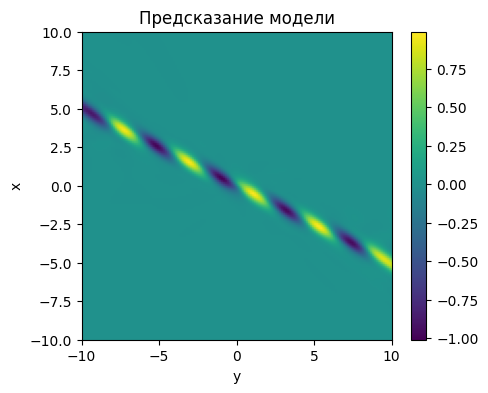

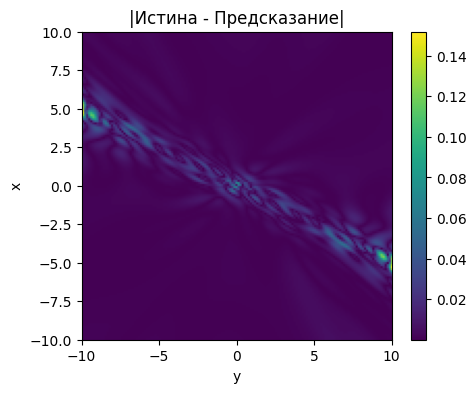

In [15]:

#@title Сравнение на сетке: истинная функция vs предсказания (теплокарты)
# Создаём регулярную сетку для наглядности
grid_n = 150  # 150x150 = 22 500 точек для плавных карт
xs = torch.linspace(-10, 10, grid_n)
ys = torch.linspace(-10, 10, grid_n)
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

with torch.no_grad():
    true_grid = target_function(Xg, Yg).cpu().numpy()

# Предсказания модели
with torch.no_grad():
    XY_in = torch.stack([Xg.reshape(-1), Yg.reshape(-1)], dim=1).to(device)
    pred_grid = model(XY_in).reshape(grid_n, grid_n).detach().cpu().numpy()

# Теплокарта истинной функции
plt.figure(figsize=(5,4))
plt.imshow(true_grid, extent=[-10, 10, -10, 10], origin='lower', aspect='auto')
plt.colorbar()
plt.title("Истинная функция f(x, y)")
plt.xlabel("y")
plt.ylabel("x")
plt.show()

# Теплокарта предсказаний модели
plt.figure(figsize=(5,4))
plt.imshow(pred_grid, extent=[-10, 10, -10, 10], origin='lower', aspect='auto')
plt.colorbar()
plt.title("Предсказание модели")
plt.xlabel("y")
plt.ylabel("x")
plt.show()

# Теплокарта абсолютной ошибки
err = np.abs(true_grid - pred_grid)
plt.figure(figsize=(5,4))
plt.imshow(err, extent=[-10, 10, -10, 10], origin='lower', aspect='auto')
plt.colorbar()
plt.title("|Истина - Предсказание|")
plt.xlabel("y")
plt.ylabel("x")
plt.show()


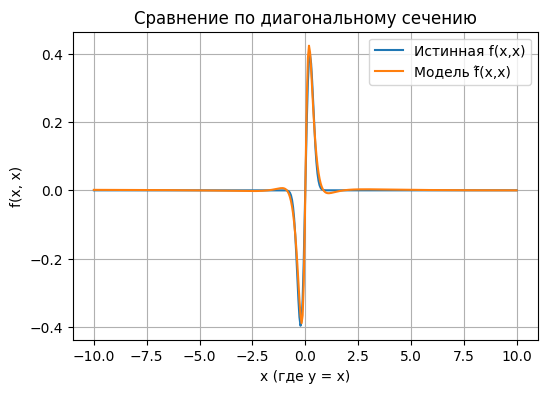

In [16]:

#@title Сравнение по сечению: диагональ x = y
line_n = 400
line = torch.linspace(-10, 10, line_n)
x_line = line
y_line = line

with torch.no_grad():
    true_line = target_function(x_line, y_line).cpu().numpy()
    pred_line = model(torch.stack([x_line, y_line], dim=1).to(device)).squeeze(1).cpu().numpy()

plt.figure(figsize=(6,4))
plt.plot(line.cpu().numpy(), true_line, label="Истинная f(x,x)")
plt.plot(line.cpu().numpy(), pred_line, label="Модель f̂(x,x)")
plt.xlabel("x (где y = x)")
plt.ylabel("f(x, x)")
plt.title("Сравнение по диагональному сечению")
plt.grid(True)
plt.legend()
plt.show()



## Итого
Сетки в три скрытых слоя с tanh активацией хватает для примерно четвертого знака после запятой. Скорее всего хватило бы и меньше.